### Text to Embeddings

In [13]:
import os
from pathlib import Path
import requests
import numpy as np
import pandas as pd
from dotenv import load_dotenv

In [2]:
load_dotenv()  # loads .env into environment variables
secret_key = os.getenv("HUGGINGFACE_API_TOKEN")
# print(f"Your secret key is: {secret_key}")

In [3]:
# example text snippets we want to translate into vector embeddings
text_chunks = [
    "The sky is blue.",
    "The grass is green.",
    "The sun is shining.",
    "I love chocolate.",
    "Pizza is delicious.",
    "Coding is fun.",
    "Roses are red.",
    "Violets are blue.",
    "Water is essential for life.",
    "The moon orbits the Earth.",
    # "The sun rises in the east.",
]

In [4]:
def _get_embeddings(text_chunk, secret_key=secret_key):
    '''
    Use embedding model from hugging face to calculate embeddings for the text snippets provided
    Parameters:
        - text_chunk (string): the sentence or text snippet you want to translate into embeddings
    Returns:
        - embedding(list): list with all embedding dimensions
    '''
    # define the embedding model you want to use
    model_id = "sentence-transformers/all-MiniLM-L6-v2"
    # you can find the token to the hugging face api in your settings page https://huggingface.co/settings/tokens
    # hf_token = os.environ.get('hf_token')

    # API endpoint for embedding model
    # api_url = f"https://api-inference.huggingface.co/pipeline/feature-extraction/{model_id}"
    api_url = f"https://router.huggingface.co/pipeline/feature-extraction/{model_id}"
    headers = {"Authorization": f"Bearer {secret_key}"}  # {hf_token}"}
    # call API
    response = requests.post(api_url, headers=headers, json={"inputs": text_chunk, "options":{"wait_for_model":True}})
    # load response from embedding model into json format
    embedding = response.json()

    return embedding
# _get_embeddings("This is a sample sentence")

In [5]:
def from_text_to_embeddings(text_chunks):
    '''
    Translate sentences into vector embeddings

    Attributes:
        - text_chunks (list): list of example strings

    Returns:
        - embeddings_df (DataFrame): data frame with the columns "text_chunk" and "embeddings"
    '''
    # create new data frame using text chunks list
    embeddings_df = pd.DataFrame(text_chunks).rename(columns={0:"text_chunk"})

    # use the _get_embeddings function to retrieve the embeddings for each of the sentences
    embeddings_df["embeddings"] = embeddings_df["text_chunk"].apply(_get_embeddings)

    # split the embeddings column into individuell columns for each vector dimension
    embeddings_df = embeddings_df['embeddings'].apply(pd.Series)
    embeddings_df["text_chunk"] = text_chunks

    return embeddings_df
# get embeddings for each of the text chunks
embeddings_df = from_text_to_embeddings(text_chunks)
embeddings_df

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

- The above way of getting vector embedding for text, mentioned in the article, is not working. I've tried to fix it with several ways, but failed. 
- I didn't keep all the cells, it was unnecesssarily cluttering the notebook.
- But few issues that I remember: 'https://api-inference.huggingface.co is no longer supported. Please use https://router.huggingface.co instead.', etc. Even after solving that it was throwing error.
- Then encountered that any url I put by default it is going to the similarity endpoint, but I need embedding or feature extraction. 

Leaving all of these, I'm now implementing the way huggingface official page suggests. 

In [7]:
from huggingface_hub import InferenceClient

In [8]:
def _get_embeddings(text_chunk, secret_key=secret_key):
    '''
    Use embedding model from hugging face to calculate embeddings for the text snippets provided
    Parameters:
        - text_chunk (string): the sentence or text snippet you want to translate into embeddings
    Returns:
        - embedding(list): list with all embedding dimensions
    '''
    # define the embedding model you want to use
    model_id = "sentence-transformers/all-MiniLM-L6-v2"
    client = InferenceClient(
        provider="hf-inference",
        api_key=secret_key,
    )
    embedding = client.feature_extraction(
        text_chunk,
        model=model_id
    )
    return embedding
_get_embeddings("This is a sample sentence").shape

(384,)

In [9]:
def from_text_to_embeddings(text_chunks):
    '''
    Translate sentences into vector embeddings

    Attributes:
        - text_chunks (list): list of example strings

    Returns:
        - embeddings_df (DataFrame): data frame with the columns "text_chunk" and "embeddings"
    '''
    # create new data frame using text chunks list
    embeddings_df = pd.DataFrame(text_chunks).rename(columns={0:"text_chunk"})

    # use the _get_embeddings function to retrieve the embeddings for each of the sentences
    embeddings_df["embeddings"] = embeddings_df["text_chunk"].apply(_get_embeddings)

    # split the embeddings column into individuell columns for each vector dimension
    embeddings_df = embeddings_df['embeddings'].apply(pd.Series)
    embeddings_df["text_chunk"] = text_chunks

    return embeddings_df
# get embeddings for each of the text chunks
embeddings_df = from_text_to_embeddings(text_chunks)
embeddings_df

,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,text_chunk
0,0.017919,0.013529,0.042797,0.016718,0.029824,0.005007,0.099299,-0.027315,0.034454,0.021490,...,-0.069639,-0.001569,0.046481,0.044527,-0.022499,-0.026074,0.004904,-0.082317,0.057050,The sky is blue.
1,-0.013632,0.039121,0.000311,-0.052031,0.030196,0.012842,0.069380,-0.023630,0.056167,0.082404,...,-0.046236,-0.079765,-0.000224,0.014226,-0.028482,-0.089305,-0.032563,0.022049,-0.000425,The grass is green.
2,0.009922,0.103157,0.080868,0.099621,0.015853,-0.015550,0.102033,-0.048798,0.036669,-0.018692,...,-0.070990,-0.017039,0.018214,-0.005125,-0.003283,0.010119,-0.000876,-0.041529,0.065692,The sun is shining.
3,-0.013325,-0.069104,0.072573,0.089983,-0.036386,0.032573,0.069601,0.027260,0.023855,0.039682,...,-0.019429,-0.015286,-0.022330,0.006549,-0.043945,0.127638,0.022927,0.001795,-0.045394,I love chocolate.
4,-0.063008,0.048133,0.017000,0.063542,-0.149114,-0.011231,0.022222,-0.010401,0.027021,-0.086515,...,0.013151,0.034347,0.116219,0.054751,0.099216,0.034592,0.047085,0.102640,-0.070935,Pizza is delicious.
5,-0.029901,-0.024532,-0.023040,-0.010303,-0.032580,-0.028407,0.002710,-0.015029,0.017583,0.080396,...,-0.017599,-0.046041,-0.000196,0.003432,0.124615,0.007950,0.096829,-0.001162,0.020002,Coding is fun.
6,-0.036743,-0.017649,0.040038,0.022469,-0.019163,0.063196,0.035273,-0.071455,0.074093,-0.024345,...,-0.061623,-0.018980,0.058972,0.011959,0.086161,0.070645,-0.031470,0.046312,0.051016,Roses are red.
7,0.009293,-0.044102,0.049137,0.047538,-0.025757,0.048172,0.074121,-0.057919,0.024806,0.019586,...,-0.086700,0.022601,0.071761,0.016644,0.002980,0.009603,-0.041864,0.030171,0.021975,Violets are blue.
8,-0.027131,0.090442,0.047263,0.024486,0.117123,0.011100,0.085536,-0.052230,-0.011343,-0.017015,...,0.072214,0.026312,-0.008613,-0.042621,-0.037052,0.057948,0.017495,0.071934,-0.024622,Water is essential for life.
9,0.066438,0.001159,0.061233,0.004431,-0.057121,-0.053252,0.008824,-0.021487,0.034589,-0.025045,...,0.030991,-0.023708,-0.023717,0.030156,0.059900,-0.008860,0.071864,0.033658,-0.018788,The moon orbits the Earth.


Now I am getting

In [10]:
# os.getcwd()
# os.listdir('.')

In [14]:
save_dir = Path("saved_artifacts/")
save_dir.mkdir(exist_ok=True)
save_path = save_dir / "embeddings_df.csv"

In [15]:
# save data frame with text chunks and embeddings to csv
embeddings_df.to_csv(save_path, index=False)

### Plotting 384D vector in 2D using PCA

In [16]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [17]:
savepath = "saved_artifacts/principal_component_plot.png"
def create_scatter_plot(df_reduced, savepath=savepath):
    plt.scatter(df_reduced['PC1'], df_reduced['PC2'], label=df_reduced['PC2'])
    # Add labels and title
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Scatter Plot')
    # Add labels to each dot
    for i, label in enumerate(embeddings_df.iloc[: , -1].to_list()):
        plt.text(df_reduced['PC1'][i], df_reduced['PC2'][i], label)
    # Save and display the plot
    print(os.getcwd())
    plt.show()
    # if input("Do you want to save? (y/yes to save): ").strip().lower() in ['y', 'yes']:
    #     plt.savefig(savepath, format='png')
    plt.savefig(savepath, format='png')
    print(f"Plot saved as: {savepath}")

In [18]:
def create_pca_plot(embeddings_df):
    '''
    The function performs a principal component analysis to reduce the dimensions to 2 so we can print them in a plot
    Parameters
        - embeddings_df (DataFrame): data frame with the columns "text_chunk" and "embeddings"
    Returns
        - df_reduced (DataFrame): data frame with the 2 most relevant Principal Components
    '''
    # Perform PCA with 2 components
    pca = PCA(n_components=2)

    # apply principal component analysis to the embeddings table
    df_reduced = pca.fit_transform(embeddings_df[embeddings_df.columns[:-2]])
    # Create a new DataFrame with reduced dimensions
    df_reduced = pd.DataFrame(df_reduced, columns=['PC1', 'PC2'])
    # create and save scatter plot
    create_scatter_plot(df_reduced=df_reduced)
    return df_reduced

/mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/learn-by-rebuilding/vector-embedding-store/all-you-need-to-know-vector-db


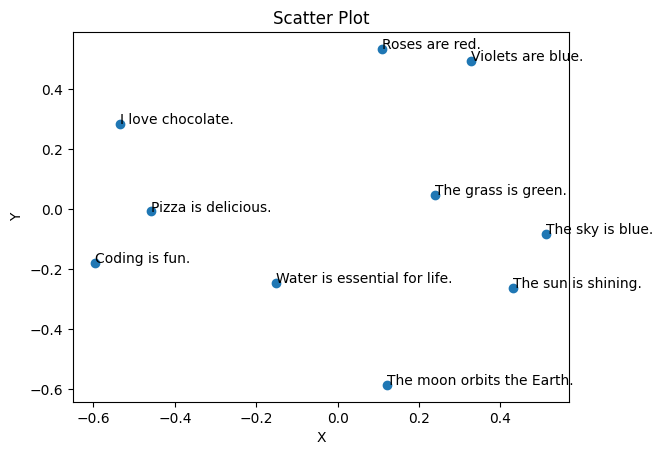

Plot saved as: saved_artifacts/principal_component_plot.png


<Figure size 640x480 with 0 Axes>

In [19]:
# Load embeddings_df.csv into data frame
embeddings_df = pd.read_csv('saved_artifacts/embeddings_df.csv')
# use the function create_pca_plot to
df_reduced = create_pca_plot(embeddings_df)

- PCA is running smoothly and also plotted the 2D embeddings as scattered plot.
- The concept convayed in the article is clearly visible that similar texts are clubbing together. 

### Calculate the distance

In [20]:
import os
import time
import numpy as np
import pandas as pd
from numpy.linalg import norm

In [21]:
def calculate_cosine_similarity(text_chunk, embeddings_df):
    '''
    Calculate the cosine similarity between the query sentence and every other sentence
    1. Get the embeddings for the text chunk
    2. Calculate the cosine similarity between the embeddings of our text chunk und every other entry in the data frame
    Parameters:
        - text_chunk (string): the text snippet we want to use to look for similar entries in our database (embeddings_df)
        - embeddings_df (DataFrame): data frame with the columns "text_chunk" and "embeddings"
    Returns:
        - embeddings_cosine_df (DataFrame): data frame with cosine distance similarity score
    '''

    # use the _get_embeddings function the retrieve the embeddings for the text chunk
    sentence_embedding = _get_embeddings(text_chunk)
    # combine all dimensions of the vector embeddings to one array
    embeddings_df['embeddings_array'] = embeddings_df.apply(lambda row: row.values[:-1], axis=1)

    # start the timer
    start_time = time.time()
    print(f"start_time : {start_time}")
    # create a list to store the calculated cosine similarity
    cos_sim = []
    for index, row in embeddings_df.iterrows():
        A = row.embeddings_array
        B = sentence_embedding
        # calculate the cosine similarity
        cosine = np.dot(A,B)/(norm(A)*norm(B))
        cos_sim.append(cosine)
    embeddings_cosine_df = embeddings_df
    embeddings_cosine_df["cos_sim"] = cos_sim
    embeddings_cosine_df.sort_values(by=["cos_sim"], ascending=False)
    # stop the timer
    end_time = time.time()
    # calculate the time needed to calculate the similarities
    elapsed_time = (end_time - start_time)
    print("Execution Time: ", elapsed_time, "seconds")
    return embeddings_cosine_df

In [22]:
# Load embeddings_df.csv into data frame
embeddings_df = pd.read_csv('saved_artifacts/embeddings_df.csv')

# test query sentence
text_chunk = "Lilies are white."

# calculate cosine similarity
embeddings_cosine_df = calculate_cosine_similarity(text_chunk, embeddings_df)
# save data frame with text chunks and embeddings to csv
embeddings_cosine_df.to_csv('saved_artifacts/embeddings_cosine_df.csv', index=False)

# rank based on similarity
similarity_ranked_df = embeddings_cosine_df[["text_chunk", "cos_sim"]].sort_values(by=["cos_sim"], ascending=False)
similarity_ranked_df

start_time : 1774618382.0646589
Execution Time:  0.03415703773498535 seconds


,text_chunk,cos_sim
7,Violets are blue.,0.345222
6,Roses are red.,0.283481
1,The grass is green.,0.233857
3,I love chocolate.,0.189652
0,The sky is blue.,0.164218
2,The sun is shining.,0.122027
4,Pizza is delicious.,0.073361
9,The moon orbits the Earth.,0.067709
8,Water is essential for life.,0.047207
5,Coding is fun.,-0.017563


Cosine distance vs similarity score:
- text


Time context:

### Store vector embeddings in a vector DB

In [23]:
import chromadb
import pandas as pd
from chromadb.config import Settings

In [24]:
# vector store settings
VECTOR_STORE_PATH = 'ChromaDB_Vectorstore/'
COLLECTION_NAME = 'my_collection'

# Load embeddings_df.csv into data frame
embeddings_df = pd.read_csv('saved_artifacts/embeddings_df.csv')

def get_or_create_client_and_collection(VECTOR_STORE_PATH, COLLECTION_NAME):
    # get/create a chroma client
    chroma_client = chromadb.PersistentClient(path=VECTOR_STORE_PATH)
    # get or create collection
    collection = chroma_client.get_or_create_collection(name=COLLECTION_NAME)
    return collection

# get or create collection
collection = get_or_create_client_and_collection(VECTOR_STORE_PATH, COLLECTION_NAME)

In [25]:
# Load embeddings_df.csv into data frame
embeddings_df = pd.read_csv('saved_artifacts/embeddings_df.csv')

def add_to_collection(embeddings_df):
    # add a sample entry to collection
    # collection.add(
    #     documents=["This is a document", "This is another document"],
    #     metadatas=[{"source": "my_source"}, {"source": "my_source"}],
    #     ids=["id1", "id2"]
    # )

    # combine all dimensions of the vector embeddings to one array
    embeddings_df['embeddings_array'] = embeddings_df.apply(lambda row: row.values[:-1], axis=1)
    embeddings_df['embeddings_array'] = embeddings_df['embeddings_array'].apply(lambda x: x.tolist())
    # add data frame to collection
    collection.add(
        embeddings=embeddings_df.embeddings_array.to_list(),
        documents=embeddings_df.text_chunk.to_list(),
        # create a list of string as index
        ids=list(map(str, embeddings_df.index.tolist()))
    )
# add the embeddings_df to our vector store collection
add_to_collection(embeddings_df)

In [26]:
os.listdir()

['.gitignore',
 '.ipynb_checkpoints',
 'ChromaDB_Vectorstore',
 'experiments.ipynb',
 'implementation.ipynb',
 'readme.md',
 'requirements.txt',
 'saved_artifacts']

In [27]:
def get_all_entries(collection):
    # query collection
    existing_docs = pd.DataFrame(collection.get()).rename(columns={0: "ids", 1:"embeddings", 2:"documents", 3:"metadatas"})
    existing_docs.to_excel("saved_artifacts/vector_stores_export.xlsx")
    return existing_docs

# extract all entries in vector store collection
existing_docs = get_all_entries(collection)

ValueError: All arrays must be of the same length

`get_all_entries` function is throwing error.
Need to debug!!
Let's print and observe what `collection.get()` returns, probably there will be some length mismatch.

In [28]:
collection.get()
# len(collection.get()['ids']), len(collection.get()['embeddings']), len(collection.get()['documents']), len(collection.get()['metadatas']), 

{'ids': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'],
 'embeddings': None,
 'documents': ['The sky is blue.',
  'The grass is green.',
  'The sun is shining.',
  'I love chocolate.',
  'Pizza is delicious.',
  'Coding is fun.',
  'Roses are red.',
  'Violets are blue.',
  'Water is essential for life.',
  'The moon orbits the Earth.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [None, None, None, None, None, None, None, None, None, None]}

**Why the error?**
- Some values are lists (ids, documents), len is 10. 
- Some are None (embeddings, data)
- Some have different lengths

Pandas requires all columns to have the same length, but here they don’t
- The issue is `collection.get()` returns:
    - 'embeddings': None
- That’s because Chroma does not return embeddings by default.

To include embeddings:
- Need to use `include` paramater: `data = collection.get(include=["embeddings", "documents", "metadatas"])`

In [29]:
collection.get(include=["embeddings", "documents", "metadatas"])

{'ids': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'],
 'embeddings': array([[ 0.01791946,  0.01352884,  0.04279672, ...,  0.00490405,
         -0.08231701,  0.05704978],
        [-0.01363221,  0.0391215 ,  0.0003112 , ..., -0.03256259,
          0.02204934, -0.00042535],
        [ 0.00992179,  0.10315739,  0.08086774, ..., -0.00087553,
         -0.04152891,  0.06569239],
        ...,
        [ 0.00929255, -0.04410242,  0.04913662, ..., -0.04186419,
          0.03017079,  0.02197453],
        [-0.02713135,  0.09044234,  0.04726324, ...,  0.01749506,
          0.07193433, -0.02462233],
        [ 0.06643756,  0.00115865,  0.06123322, ...,  0.07186381,
          0.03365781, -0.01878847]], shape=(10, 384)),
 'documents': ['The sky is blue.',
  'The grass is green.',
  'The sun is shining.',
  'I love chocolate.',
  'Pizza is delicious.',
  'Coding is fun.',
  'Roses are red.',
  'Violets are blue.',
  'Water is essential for life.',
  'The moon orbits the Earth.'],
 'uris': None,
 'in

In [30]:
def get_all_entries(collection):
    # query collection
    data = collection.get(include=["embeddings", "documents", "metadatas"])
    existing_docs = pd.DataFrame(data)
    existing_docs.to_excel("saved_artifacts/vector_stores_export.xlsx")
    return existing_docs

# extract all entries in vector store collection
existing_docs = get_all_entries(collection)
existing_docs

ValueError: Per-column arrays must each be 1-dimensional

**Another Error:** Here the issue is:
- `embeddings` column is not 1D array, need to convert this into list. 

In [31]:
data = collection.get(include=["embeddings", "documents", "metadatas"])
# pd.DataFrame(data)
data["embeddings"].shape

(10, 384)

In [32]:
def get_all_entries(collection):
    # query collection
    data = collection.get(include=["embeddings", "documents", "metadatas"])
    existing_docs = pd.DataFrame({
        "ids": data["ids"],
        "documents": data["documents"],
        "metadatas": data["metadatas"],
        "embeddings": data["embeddings"].tolist()
    })
    existing_docs.to_excel("saved_artifacts/vector_stores_export.xlsx")
    return existing_docs

# extract all entries in vector store collection
existing_docs = get_all_entries(collection)
existing_docs

,ids,documents,metadatas,embeddings
0,0,The sky is blue.,None,"[0.017919456586241722, 0.013528835028409958, 0..."
1,1,The grass is green.,None,"[-0.013632207177579403, 0.03912149742245674, 0..."
2,2,The sun is shining.,None,"[0.009921791031956673, 0.10315738618373871, 0...."
3,3,I love chocolate.,None,"[-0.013325375504791737, -0.06910396367311478, ..."
4,4,Pizza is delicious.,None,"[-0.06300842016935349, 0.04813253507018089, 0...."
5,5,Coding is fun.,None,"[-0.02990063838660717, -0.024532051756978035, ..."
6,6,Roses are red.,None,"[-0.03674331307411194, -0.01764916256070137, 0..."
7,7,Violets are blue.,None,"[0.009292551316320896, -0.04410242289304733, 0..."
8,8,Water is essential for life.,None,"[-0.027131348848342896, 0.09044233709573746, 0..."
9,9,The moon orbits the Earth.,None,"[0.06643755733966827, 0.0011586514301598072, 0..."


### Query the collection

In [34]:
def query_vector_database(VECTOR_STORE_PATH, COLLECTION_NAME, query, n=2):
    # query collection
    results = collection.query(
        query_texts=query,
        n_results=n
    )
    print(f"Similarity Search: {n} most similar entries:")
    print(results["documents"])
    return results

# similarity search
similar_vector_entries = query_vector_database(VECTOR_STORE_PATH, COLLECTION_NAME, query=["Lilies are white."])


Similarity Search: 2 most similar entries:
[['Violets are blue.', 'Roses are red.']]


In [35]:
similar_vector_entries = query_vector_database(VECTOR_STORE_PATH, COLLECTION_NAME, query=["Lilies are white."])
similar_vector_entries

Similarity Search: 2 most similar entries:
[['Violets are blue.', 'Roses are red.']]


{'ids': [['7', '6']],
 'embeddings': None,
 'documents': [['Violets are blue.', 'Roses are red.']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[None, None]],
 'distances': [[1.3095569610595703, 1.433037519454956]]}

In [36]:
similar_vector_entries = query_vector_database(VECTOR_STORE_PATH, COLLECTION_NAME, query=["The earth orbits the sun."])
similar_vector_entries

Similarity Search: 2 most similar entries:
[['The moon orbits the Earth.', 'The sun is shining.']]


{'ids': [['9', '2']],
 'embeddings': None,
 'documents': [['The moon orbits the Earth.', 'The sun is shining.']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[None, None]],
 'distances': [[0.5676224827766418, 0.8526027798652649]]}